# PCOS Survey Data Cleaning and Harmonization

## Introduction
This notebook is performing the cleaning and harmonization stage for the self-reported PCOS survey dataset used in the MSc study on early, non-invasive PCOS prediction. Unlike the main clinical dataset, this survey file is containing participant-reported lifestyle and symptom information rather than clinically measured laboratory or imaging variables. For that reason, the dataset is being treated as a valuable but lower-certainty source that requires careful preprocessing before it can support downstream validation.

The current raw survey file is containing 465 responses across 16 variables. These responses are being used to test whether the non-invasive feature set can generalize beyond the main clinical dataset and support external-style validation with real-world self-reported inputs.

## Research Context
The broader study is investigating whether routinely obtainable, low-burden indicators can support practical early screening for Polycystic Ovary Syndrome (PCOS), especially in settings where specialist tests or imaging are difficult to access. Within that context, this notebook is preparing a non-clinical survey dataset that can help evaluate how well the future model behaves when the input data are self-reported rather than clinically captured.

This notebook is therefore supporting:
- non-invasive feature harmonization
- external-style validation design
- portability checks across data sources
- later model robustness analysis

## What This Notebook Is Doing
This notebook is:
- loading and auditing the survey dataset
- standardizing the survey column names into a stable schema
- converting mixed height formats into centimeters
- normalizing binary symptom and lifestyle indicators to `0/1`
- deriving BMI and an approximate cycle-length feature for contract alignment
- validating ranges and imputing any missing values created during cleaning
- exporting the full cleaned survey table for later validation work

## Expected Output
The primary output of this notebook is a cleaned survey dataset saved as:

`./cleaned_data/PCOS_survey_cleaned.csv`

Supporting outputs are also being saved for traceability, including a cleaning log, a compact quality summary, and diagnostic figures written to `./images/`.

## Notebook Structure
The sections that are following are being organized as a step-by-step harmonization workflow:

1. **Reproducibility Setup and Path Configuration**  
   The environment and file paths are being prepared for stable execution.

2. **Data Loading and Initial Inspection**  
   The raw survey file is being reviewed for structure, duplicates, and initial data quality.

3. **Column Standardization and Schema Alignment**  
   The survey headers are being renamed into a consistent, research-friendly format.

4. **Cleaning and Feature Engineering**  
   Height, BMI, cycle features, and binary variables are being harmonized into analysis-ready form.

5. **Validation and Diagnostic Review**  
   Range checks, missing-value handling, and diagnostic plots are being produced.

6. **Dataset Export and Summary**  
   The full cleaned survey table is being exported, while a contract-aligned modeling view is also being displayed inside the notebook.

## Reproducibility Note
All paths in this notebook are being kept relative to the project structure, and all transformations that affect the analytical dataset are being documented so that the workflow can be rerun and audited later.

## Reproducibility Setup and Path Configuration

This section is importing the required libraries, resolving the project root, and preparing the directories needed for cleaned data exports and diagnostic figures.

In [1]:
# Importing the libraries that are supporting survey cleaning, validation, and figure export.
from pathlib import Path
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Importing seaborn when it is available improves plot defaults, while a matplotlib fallback keeps the notebook portable.
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
except ImportError:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

# Setting the display options keeps the wide survey table readable during inspection.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

# Fixing the seed preserves reproducibility for any future sampling or stochastic checks.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolving the project root dynamically allows the notebook to run from the repo root or the notebooks directory.
def resolve_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'data' / 'PCOS_survey.csv').exists():
            return candidate
    raise FileNotFoundError('The survey dataset could not be located relative to the current working directory.')

PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'PCOS_survey.csv'
CLEANED_DIR = PROJECT_ROOT / 'cleaned_data'
IMAGE_DIR = PROJECT_ROOT / 'images'

# Creating the output folders keeps the notebook idempotent across reruns.
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f'**Project root:** `{PROJECT_ROOT}`'))
display(Markdown(f'**Raw survey file:** `{DATA_PATH}`'))
display(Markdown(f'**Cleaned data directory:** `{CLEANED_DIR}`'))
display(Markdown(f'**Image directory:** `{IMAGE_DIR}`'))

**Project root:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic`

**Raw survey file:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\data\PCOS_survey.csv`

**Cleaned data directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data`

**Image directory:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images`

## Data Loading and Initial Inspection

This section is loading the raw survey dataset and reviewing its structure, schema, missingness, and duplicate pattern before any harmonization is being applied.

In [2]:
# Reading the survey file with UTF-8 BOM handling keeps the column names intact if the CSV contains a signature marker.
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Showing the first rows provides a quick check of the self-reported schema and raw value patterns.
df_raw.head(10)

,Age (in Years),Weight (in Kg),Height (in Cm / Feet),Can you tell us your blood group ?,After how many months do you get your periods?\n(select 1- if every month/regular),Have you gained weight recently?,Do you have excessive body/facial hair growth ?,Are you noticing skin darkening recently?,Do have hair loss/hair thinning/baldness ?,Do you have pimples/acne on your face/jawline ?,Do you eat fast food regularly ?,Do you exercise on a regular basis ?,Have you been diagnosed with PCOS/PCOD?,Do you experience mood swings ?,Are your periods regular ?,"How long does your period last ? (in Days)\nexample- 1,2,3,4....."
0,21,47.000,168.000,13,1,0,0,0,0,0,0,0,0,1,1,6
1,21,45.000,156.000,11,1,0,0,1,1,1,0,0,0,1,1,4
2,17,37.000,162.000,15,1,0,0,0,0,1,1,0,0,1,1,6
3,28,54.000,160.000,15,1,0,0,0,0,0,0,0,0,1,1,4
4,45,40.000,150.000,13,2,0,0,0,1,0,0,0,1,1,0,7
5,16,70.000,167.000,13,2,0,1,1,0,0,0,1,0,0,0,7
6,20,48.000,147.000,13,1,0,0,0,0,1,1,1,0,1,1,5
7,21,55.000,152.000,15,1,0,0,0,0,1,0,0,0,1,1,5
8,40,68.000,157.000,13,1,0,0,0,0,0,0,0,1,1,0,4
9,38,62.000,153.000,11,1,1,0,1,1,0,0,0,0,1,1,1


In [3]:
# Capturing the dataframe info in a buffer makes the schema easier to display in the notebook.
info_buffer = io.StringIO()
df_raw.info(buf=info_buffer)

# Building compact inspection tables keeps the initial audit readable and report-friendly.
raw_shape_df = pd.DataFrame(
    {
        'metric': ['rows', 'columns'],
        'value': [df_raw.shape[0], df_raw.shape[1]],
    }
)
raw_missing_summary = (
    pd.DataFrame(
        {
            'column': df_raw.columns,
            'missing_count': df_raw.isna().sum().values,
            'missing_percentage': (df_raw.isna().sum().values / len(df_raw)) * 100,
        }
    )
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
raw_duplicate_rows = int(df_raw.duplicated().sum())

display(Markdown('### Raw Dataset Shape'))
display(raw_shape_df)
display(Markdown('### Raw Data Types'))
print(info_buffer.getvalue())
display(Markdown('### Descriptive Statistics (All Columns)'))
display(df_raw.describe(include='all').T)
display(Markdown('### Missing-Value Summary'))
display(raw_missing_summary)
display(Markdown('### Duplicate Summary'))
display(pd.DataFrame({'check': ['Exact duplicate rows'], 'count': [raw_duplicate_rows]}))

### Raw Dataset Shape

,metric,value
0,rows,465
1,columns,16


### Raw Data Types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 16 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Age (in Years)                                                                     465 non-null    int64  
 1   Weight (in Kg)                                                                     465 non-null    float64
 2   Height (in Cm / Feet)                                                              465 non-null    float64
 3   Can you tell us your blood group ?                                                 465 non-null    int64  
 4   After how many months do you get your periods?
(select 1- if every month/regular)  465 non-null    int64  
 5   Have you gained weight recently?                                                   465 non-null    int64  

### Descriptive Statistics (All Columns)

,count,mean,std,min,25%,50%,75%,max
Age (in Years),465.000,25.456,8.100,13.000,20.000,22.000,28.000,58.000
Weight (in Kg),465.000,59.287,11.137,33.000,51.000,58.000,65.000,100.000
Height (in Cm / Feet),465.000,157.916,14.933,4.000,154.000,160.000,164.000,186.000
Can you tell us your blood group ?,465.000,13.262,1.500,11.000,13.000,13.000,15.000,16.000
After how many months do you get your periods?\n(select 1- if every month/regular),465.000,1.222,0.542,1.000,1.000,1.000,1.000,3.000
Have you gained weight recently?,465.000,0.501,0.501,0.000,0.000,1.000,1.000,1.000
Do you have excessive body/facial hair growth ?,465.000,0.265,0.442,0.000,0.000,0.000,1.000,1.000
Are you noticing skin darkening recently?,465.000,0.338,0.473,0.000,0.000,0.000,1.000,1.000
Do have hair loss/hair thinning/baldness ?,465.000,0.619,0.486,0.000,0.000,1.000,1.000,1.000
Do you have pimples/acne on your face/jawline ?,465.000,0.413,0.493,0.000,0.000,0.000,1.000,1.000


### Missing-Value Summary

,column,missing_count,missing_percentage
0,After how many months do you get your periods?...,0,0.000
1,Age (in Years),0,0.000
2,Are you noticing skin darkening recently?,0,0.000
3,Are your periods regular ?,0,0.000
4,Can you tell us your blood group ?,0,0.000
5,Do have hair loss/hair thinning/baldness ?,0,0.000
6,Do you eat fast food regularly ?,0,0.000
7,Do you exercise on a regular basis ?,0,0.000
8,Do you experience mood swings ?,0,0.000
9,Do you have excessive body/facial hair growth ?,0,0.000


### Duplicate Summary

,check,count
0,Exact duplicate rows,1


## Column Standardization and Schema Alignment

The survey headers are now being renamed into a stable schema that is easy to reference across later notebooks and external-validation code.

In [4]:
# Copying the raw dataframe keeps the original import intact for comparison and traceability.
df = df_raw.copy()
transformation_log = []

# Recording cleaning steps in a structured log keeps the workflow transparent and exportable.
def log_transformation(step: str, detail: str, affected_items: int) -> None:
    transformation_log.append(
        {
            'step': step,
            'detail': detail,
            'affected_items': affected_items,
        }
    )

# Defining the rename map explicitly prevents schema drift between notebooks.
rename_map = {
    'Age (in Years)': 'age_yrs',
    'Weight (in Kg)': 'weight_kg',
    'Height (in Cm / Feet)': 'height_raw',
    'Can you tell us your blood group ?': 'blood_group_code',
    'After how many months do you get your periods?\n(select 1- if every month/regular)': 'months_between_periods',
    'Have you gained weight recently?': 'weight_gain_y_n',
    'Do you have excessive body/facial hair growth ?': 'hair_growth_y_n',
    'Are you noticing skin darkening recently?': 'skin_darkening_y_n',
    'Do have hair loss/hair thinning/baldness ?': 'hair_loss_y_n',
    'Do you have pimples/acne on your face/jawline ?': 'pimples_y_n',
    'Do you eat fast food regularly ?': 'fast_food_y_n',
    'Do you exercise on a regular basis ?': 'regular_exercise_y_n',
    'Have you been diagnosed with PCOS/PCOD?': 'pcos_y_n',
    'Do you experience mood swings ?': 'mood_swings_y_n',
    'Are your periods regular ?': 'periods_regular_y_n',
    'How long does your period last ? (in Days)\nexample- 1,2,3,4.....': 'period_duration_days',
}

# Building a rename log makes the harmonization decisions visible inside the notebook.
rename_log = pd.DataFrame(
    {
        'original_name': list(rename_map.keys()),
        'standardized_name': list(rename_map.values()),
    }
)

missing_expected_headers = [column for column in rename_map if column not in df.columns]
if missing_expected_headers:
    raise KeyError(f'Expected survey headers were not found: {missing_expected_headers}')

df = df.rename(columns=rename_map)
log_transformation('Standardized survey column names', 'Renamed the raw survey headers into the stable harmonized schema.', len(rename_map))

display(Markdown('### Raw-to-Standardized Column Mapping'))
display(rename_log)

### Raw-to-Standardized Column Mapping

,original_name,standardized_name
0,Age (in Years),age_yrs
1,Weight (in Kg),weight_kg
2,Height (in Cm / Feet),height_raw
3,Can you tell us your blood group ?,blood_group_code
4,After how many months do you get your periods?...,months_between_periods
5,Have you gained weight recently?,weight_gain_y_n
6,Do you have excessive body/facial hair growth ?,hair_growth_y_n
7,Are you noticing skin darkening recently?,skin_darkening_y_n
8,Do have hair loss/hair thinning/baldness ?,hair_loss_y_n
9,Do you have pimples/acne on your face/jawline ?,pimples_y_n


## Cleaning, Harmonization, and Feature Engineering

The survey variables are now being converted into a harmonized structure that aligns with the non-invasive modeling contract while still preserving survey-specific provenance fields in the cleaned export.

In [5]:
# Removing exact duplicate responses avoids double-counting repeated survey submissions.
duplicate_rows_removed = int(df.duplicated().sum())
if duplicate_rows_removed:
    df = df.drop_duplicates().copy()
    log_transformation('Removed duplicate survey rows', 'Dropped exact duplicate survey responses.', duplicate_rows_removed)

# Preserving the raw height entry as text supports robust parsing of mixed-unit formats such as 168, 4, 4.7, and 13.46.
height_raw_text = df['height_raw'].astype(str).str.strip()

# Converting the other fields to numeric early keeps the later validation and imputation logic consistent.
for column in df.columns:
    if column != 'height_raw':
        df[column] = pd.to_numeric(df[column], errors='coerce')

# The height parser is applying explicit rules for centimeters, feet, feet-and-inches, and malformed decimal centimeter entries.
def convert_height_to_cm(value) -> float:
    text = str(value).strip()
    if text == '' or text.lower() == 'nan':
        return np.nan
    try:
        numeric_value = float(text)
    except ValueError:
        return np.nan

    if 100 <= numeric_value <= 250:
        return numeric_value
    if text.isdigit() and 2 <= numeric_value <= 8:
        return numeric_value * 30.48
    if '.' in text:
        integer_part, decimal_part = text.split('.', 1)
        if integer_part.isdigit() and decimal_part.isdigit() and 2 <= float(integer_part) <= 8 and len(decimal_part) == 1:
            feet = int(integer_part)
            inches = int(decimal_part)
            return (feet * 30.48) + (inches * 2.54)
        if 10 <= numeric_value < 100:
            candidate_cm = numeric_value * 10
            if 120 <= candidate_cm <= 220:
                return candidate_cm
    if 2 <= numeric_value <= 8:
        return numeric_value * 30.48
    return np.nan

# Applying the conversion function creates the harmonized height feature used in the exported dataset.
df['height_cm'] = height_raw_text.apply(convert_height_to_cm)
df['height_raw'] = pd.to_numeric(height_raw_text, errors='coerce')
log_transformation('Standardized height units', 'Converted mixed survey height entries into centimeters.', int(df['height_cm'].notna().sum()))

# Building a height conversion spot-check table makes the conversion logic transparent inside the notebook.
height_conversion_examples = pd.DataFrame({'height_input': ['168', '4', '4.7', '13.46']})
height_conversion_examples['height_cm'] = height_conversion_examples['height_input'].apply(convert_height_to_cm)

# Defining the binary fields explicitly keeps the survey symptom indicators aligned with the clinical feature contract.
binary_columns = [
    'weight_gain_y_n',
    'hair_growth_y_n',
    'skin_darkening_y_n',
    'hair_loss_y_n',
    'pimples_y_n',
    'fast_food_y_n',
    'regular_exercise_y_n',
    'pcos_y_n',
    'mood_swings_y_n',
    'periods_regular_y_n',
]
binary_validation_records = []
binary_map = {'y': 1, 'n': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}

# Normalizing each binary column to 0/1 prevents schema drift when the data are later compared to the clinical dataset.
for column in binary_columns:
    as_text = (
        df[column].astype('string').str.strip().str.lower().replace({'<na>': pd.NA, 'nan': pd.NA, '': pd.NA})
    )
    normalized = as_text.map(binary_map)
    numeric_fallback = pd.to_numeric(df[column], errors='coerce')
    df[column] = normalized.fillna(numeric_fallback)
    unexpected_values = sorted(set(df[column].dropna().unique()) - {0.0, 1.0})
    binary_validation_records.append({'column': column, 'unexpected_values': unexpected_values})

# Deriving the harmonized modeling fields keeps the survey data aligned with the non-invasive contract used later for validation.
df['cycle_regularity'] = df['periods_regular_y_n']
df['cycle_length_days'] = df['months_between_periods'] * 30
df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
log_transformation('Created derived features', 'Derived height_cm, bmi, cycle_regularity, and cycle_length_days.', 4)

# Defining plausible ranges allows the notebook to separate invalid values from values that are simply uncommon.
range_rules = {
    'age_yrs': (12, 100),
    'weight_kg': (20, 250),
    'height_cm': (120, 220),
    'bmi': (10, 70),
    'cycle_length_days': (20, 120),
    'period_duration_days': (1, 15),
}
range_issues = []

# Converting implausible measurements to missing is keeping the later imputation step explicit and auditable.
for column, (lower_bound, upper_bound) in range_rules.items():
    invalid_mask = df[column].notna() & ((df[column] < lower_bound) | (df[column] > upper_bound))
    invalid_count = int(invalid_mask.sum())
    if invalid_count:
        range_issues.append({'column': column, 'lower_bound': lower_bound, 'upper_bound': upper_bound, 'flagged_rows': invalid_count})
        df.loc[invalid_mask, column] = np.nan
        log_transformation('Applied range sanity checks', f'Set implausible values to missing in {column}.', invalid_count)

# Using the mode for code-like columns preserves valid encodings, while the median is used for continuous fields.
categorical_like_columns = ['blood_group_code', 'months_between_periods', *binary_columns, 'cycle_regularity']
continuous_columns = [column for column in df.columns if column not in categorical_like_columns]
imputation_records = []

for column in categorical_like_columns:
    missing_count = int(df[column].isna().sum())
    if missing_count:
        mode_values = df[column].mode(dropna=True)
        if not mode_values.empty:
            fill_value = mode_values.iloc[0]
            df[column] = df[column].fillna(fill_value)
            imputation_records.append({'column': column, 'strategy': 'mode', 'filled_count': missing_count, 'fill_value': fill_value})
            log_transformation('Imputed categorical-like column', f'Filled missing values in {column} using the mode.', missing_count)

for column in continuous_columns:
    missing_count = int(df[column].isna().sum())
    if missing_count:
        median_value = df[column].median(skipna=True)
        if pd.notna(median_value):
            df[column] = df[column].fillna(median_value)
            imputation_records.append({'column': column, 'strategy': 'median', 'filled_count': missing_count, 'fill_value': median_value})
            log_transformation('Imputed continuous column', f'Filled missing values in {column} using the median.', missing_count)

# Recomputing the derived fields after imputation keeps the contract-aligned features consistent with their source variables.
df['cycle_regularity'] = df['periods_regular_y_n']
df['cycle_length_days'] = df['months_between_periods'] * 30
df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# Casting integer-like code columns back to integer dtype keeps the cleaned survey table easy to interpret and compare.
integer_like_columns = ['blood_group_code', 'months_between_periods', *binary_columns, 'cycle_regularity']
for column in integer_like_columns:
    series = df[column].dropna().astype(float)
    if not series.empty and np.isclose(series % 1, 0).all():
        df[column] = df[column].round().astype('Int64')

# Building the aligned modeling view makes the overlap-ready non-invasive feature contract visible without changing the saved survey table.
model_view_columns = ['age_yrs', 'weight_kg', 'height_cm', 'bmi', 'cycle_regularity', 'cycle_length_days', 'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n', 'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n', 'regular_exercise_y_n', 'pcos_y_n']
df_model = df[model_view_columns].copy()

range_issues_df = pd.DataFrame(range_issues)
imputation_log_df = pd.DataFrame(imputation_records)
binary_validation_df = pd.DataFrame(binary_validation_records)

display(Markdown('### Height Conversion Spot Checks'))
display(height_conversion_examples)
display(Markdown('### In-Notebook Modeling View'))
display(df_model.head(10))

### Height Conversion Spot Checks

,height_input,height_cm
0,168,168.000
1,4,121.920
2,4.7,139.700
3,13.46,134.600


### In-Notebook Modeling View

,age_yrs,weight_kg,height_cm,bmi,cycle_regularity,cycle_length_days,weight_gain_y_n,hair_growth_y_n,skin_darkening_y_n,hair_loss_y_n,pimples_y_n,fast_food_y_n,regular_exercise_y_n,pcos_y_n
0,21,47.000,168.000,16.652,1,30,0,0,0,0,0,0,0,0
1,21,45.000,156.000,18.491,1,30,0,0,1,1,1,0,0,0
2,17,37.000,162.000,14.098,1,30,0,0,0,0,1,1,0,0
3,28,54.000,160.000,21.094,1,30,0,0,0,0,0,0,0,0
4,45,40.000,150.000,17.778,0,60,0,0,0,1,0,0,0,1
5,16,70.000,167.000,25.100,0,60,0,1,1,0,0,0,1,0
6,20,48.000,147.000,22.213,1,30,0,0,0,0,1,1,1,0
7,21,55.000,152.000,23.805,1,30,0,0,0,0,1,0,0,0
8,40,68.000,157.000,27.587,0,30,0,0,0,0,0,0,0,1
9,38,62.000,153.000,26.486,1,30,1,0,1,1,0,0,0,0


## Validation, Diagnostic Checks, and Figures

This section is summarizing the cleaned survey quality, validating the harmonized feature contract, and exporting a small set of diagnostic figures for later reporting.

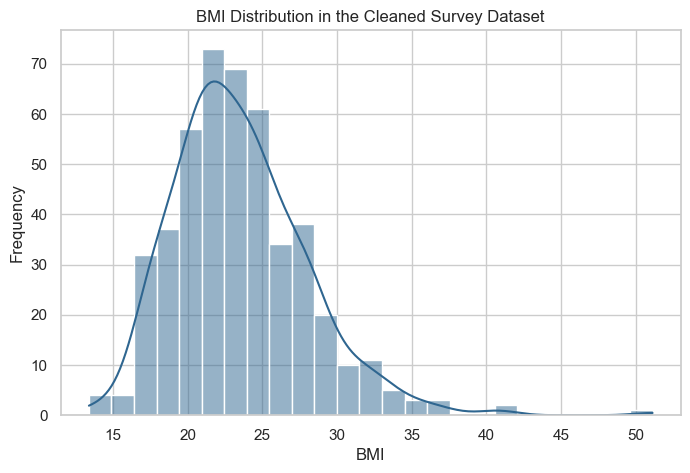

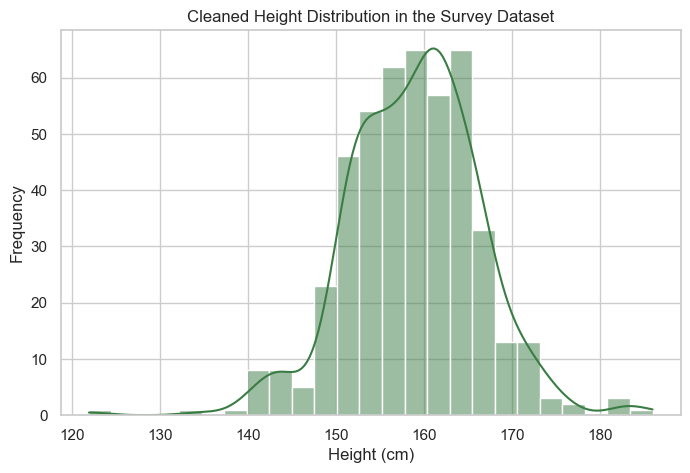

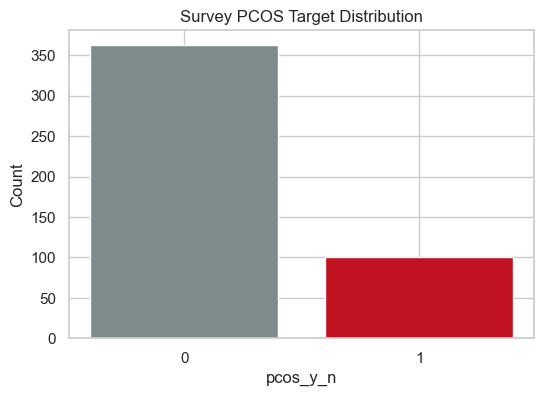

### Remaining Missingness in the Full Cleaned Survey Table

,column,missing_count,missing_percentage
0,age_yrs,0,0.000
1,blood_group_code,0,0.000
2,bmi,0,0.000
3,cycle_length_days,0,0.000
4,cycle_regularity,0,0.000
5,fast_food_y_n,0,0.000
6,hair_growth_y_n,0,0.000
7,hair_loss_y_n,0,0.000
8,height_cm,0,0.000
9,height_raw,0,0.000


### Remaining Missingness in the Modeling View

,column,missing_count,missing_percentage
0,age_yrs,0,0.000
1,bmi,0,0.000
2,cycle_length_days,0,0.000
3,cycle_regularity,0,0.000
4,fast_food_y_n,0,0.000
5,hair_growth_y_n,0,0.000
6,hair_loss_y_n,0,0.000
7,height_cm,0,0.000
8,pcos_y_n,0,0.000
9,pimples_y_n,0,0.000


### Binary Validation

...

,column,lower_bound,upper_bound,flagged_rows
0,period_duration_days,1,15,2


### Selected Numeric Summary

,count,mean,std,min,25%,50%,75%,max
age_yrs,464.000,25.466,8.106,13.000,20.000,22.500,28.000,58.000
weight_kg,464.000,59.289,11.149,33.000,51.000,58.000,65.000,100.000
height_cm,464.000,158.964,7.445,121.920,154.000,160.000,164.000,186.000
bmi,464.000,23.513,4.512,13.388,20.449,22.862,25.966,51.129
cycle_length_days,464.000,36.659,16.267,30.000,30.000,30.000,30.000,90.000
period_duration_days,464.000,4.623,1.508,1.000,4.000,5.000,5.000,15.000


### Saved Diagnostic Figures

,saved_figure
0,survey_bmi_distribution.png
1,survey_height_distribution.png
2,survey_pcos_target_distribution.png


In [6]:
# Summarizing the remaining missingness confirms whether the cleaned survey table is ready for downstream use.
remaining_missing_summary = (
    pd.DataFrame({'column': df.columns, 'missing_count': df.isna().sum().values, 'missing_percentage': (df.isna().sum().values / len(df)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)
model_view_missing_summary = (
    pd.DataFrame({'column': df_model.columns, 'missing_count': df_model.isna().sum().values, 'missing_percentage': (df_model.isna().sum().values / len(df_model)) * 100})
    .sort_values(['missing_count', 'column'], ascending=[False, True])
    .reset_index(drop=True)
)

# Creating a compact numeric summary keeps the key harmonized fields easy to audit.
selected_numeric_summary = df[['age_yrs', 'weight_kg', 'height_cm', 'bmi', 'cycle_length_days', 'period_duration_days']].describe().T

# Exporting a few lightweight figures makes the survey cleaning stage easier to review later.
saved_figures = []

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['bmi'], kde=True, bins=25, ax=ax, color='#2f6690')
else:
    ax.hist(df['bmi'].dropna(), bins=25, color='#2f6690', edgecolor='white', alpha=0.9)
ax.set_title('BMI Distribution in the Cleaned Survey Dataset')
ax.set_xlabel('BMI')
ax.set_ylabel('Frequency')
bmi_figure_path = IMAGE_DIR / 'survey_bmi_distribution.png'
fig.savefig(bmi_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(bmi_figure_path.name)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if sns is not None:
    sns.histplot(df['height_cm'], kde=True, bins=25, ax=ax, color='#3a7d44')
else:
    ax.hist(df['height_cm'].dropna(), bins=25, color='#3a7d44', edgecolor='white', alpha=0.9)
ax.set_title('Cleaned Height Distribution in the Survey Dataset')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Frequency')
height_figure_path = IMAGE_DIR / 'survey_height_distribution.png'
fig.savefig(height_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(height_figure_path.name)
plt.show()

target_counts = df['pcos_y_n'].value_counts(dropna=False).sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_counts.index.astype(str), target_counts.values, color=['#7f8c8d', '#c1121f'])
ax.set_title('Survey PCOS Target Distribution')
ax.set_xlabel('pcos_y_n')
ax.set_ylabel('Count')
target_figure_path = IMAGE_DIR / 'survey_pcos_target_distribution.png'
fig.savefig(target_figure_path, dpi=300, bbox_inches='tight')
saved_figures.append(target_figure_path.name)
plt.show()

display(Markdown('### Remaining Missingness in the Full Cleaned Survey Table'))
display(remaining_missing_summary)
display(Markdown('### Remaining Missingness in the Modeling View'))
display(model_view_missing_summary)
display(Markdown('### Binary Validation'))
display(binary_validation_df)
display(Markdown('### Range Flags'))
display(range_issues_df if not range_issues_df.empty else pd.DataFrame({'message': ['No range violations were flagged by the configured checks.']}))
display(Markdown('### Selected Numeric Summary'))
display(selected_numeric_summary)
display(Markdown('### Saved Diagnostic Figures'))
display(pd.DataFrame({'saved_figure': saved_figures}))

## Dataset Export and Cleaning Summary

The cleaned survey table is now being exported together with compact logs that document what was changed during harmonization. The export is preserving the full cleaned survey table while the aligned modeling view remains available inside the notebook for overlap-based validation.

In [7]:
# Converting the transformation history into a dataframe makes the cleaning record easy to inspect and save.
transformation_log_df = pd.DataFrame(transformation_log)

# Building a compact quality summary provides a thesis-friendly snapshot of the survey harmonization outcome.
quality_summary_df = pd.DataFrame(
    {
        'check': ['Rows in raw dataset', 'Columns in raw dataset', 'Rows in cleaned dataset', 'Columns in cleaned dataset', 'Exact duplicate rows removed', 'Columns renamed', 'Range flags handled', 'Remaining missing cells in cleaned table', 'Remaining missing cells in modeling view'],
        'value': [df_raw.shape[0], df_raw.shape[1], df.shape[0], df.shape[1], duplicate_rows_removed, len(rename_map), int(range_issues_df['flagged_rows'].sum()) if not range_issues_df.empty else 0, int(df.isna().sum().sum()), int(df_model.isna().sum().sum())],
    }
)

# Defining the export paths once keeps the saved outputs consistent with the repository layout.
cleaned_dataset_path = CLEANED_DIR / 'PCOS_survey_cleaned.csv'
transformation_log_path = CLEANED_DIR / 'PCOS_survey_cleaning_log.csv'
quality_summary_path = CLEANED_DIR / 'PCOS_survey_quality_summary.csv'

# Exporting the full cleaned survey table preserves provenance, while the modeling view stays notebook-local by design.
df.to_csv(cleaned_dataset_path, index=False)
transformation_log_df.to_csv(transformation_log_path, index=False)
quality_summary_df.to_csv(quality_summary_path, index=False)

display(Markdown(f'**Cleaned survey dataset saved to:** `{cleaned_dataset_path}`'))
display(Markdown(f'**Transformation log saved to:** `{transformation_log_path}`'))
display(Markdown(f'**Quality summary saved to:** `{quality_summary_path}`'))
display(Markdown('### Cleaning Summary Table'))
display(quality_summary_df)
display(Markdown('### Transformation Log'))
display(transformation_log_df)

# Displaying the head of the cleaned survey table confirms the exported schema and derived fields.
df.head(10)

**Cleaned survey dataset saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_survey_cleaned.csv`

**Transformation log saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_survey_cleaning_log.csv`

**Quality summary saved to:** `c:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\PCOS_survey_quality_summary.csv`

### Cleaning Summary Table

,check,value
0,Rows in raw dataset,465
1,Columns in raw dataset,16
2,Rows in cleaned dataset,464
3,Columns in cleaned dataset,20
4,Exact duplicate rows removed,1
5,Columns renamed,16
6,Range flags handled,2
7,Remaining missing cells in cleaned table,0
8,Remaining missing cells in modeling view,0


### Transformation Log

,step,detail,affected_items
0,Standardized survey column names,Renamed the raw survey headers into the stable...,16
1,Removed duplicate survey rows,Dropped exact duplicate survey responses.,1
2,Standardized height units,Converted mixed survey height entries into cen...,463
3,Created derived features,"Derived height_cm, bmi, cycle_regularity, and ...",4
4,Applied range sanity checks,Set implausible values to missing in period_du...,2
5,Imputed continuous column,Filled missing values in period_duration_days ...,2
6,Imputed continuous column,Filled missing values in height_cm using the m...,1
7,Imputed continuous column,Filled missing values in bmi using the median.,1


,age_yrs,weight_kg,height_raw,blood_group_code,months_between_periods,weight_gain_y_n,hair_growth_y_n,skin_darkening_y_n,hair_loss_y_n,pimples_y_n,fast_food_y_n,regular_exercise_y_n,pcos_y_n,mood_swings_y_n,periods_regular_y_n,period_duration_days,height_cm,cycle_regularity,cycle_length_days,bmi
0,21,47.000,168.000,13,1,0,0,0,0,0,0,0,0,1,1,6.000,168.000,1,30,16.652
1,21,45.000,156.000,11,1,0,0,1,1,1,0,0,0,1,1,4.000,156.000,1,30,18.491
2,17,37.000,162.000,15,1,0,0,0,0,1,1,0,0,1,1,6.000,162.000,1,30,14.098
3,28,54.000,160.000,15,1,0,0,0,0,0,0,0,0,1,1,4.000,160.000,1,30,21.094
4,45,40.000,150.000,13,2,0,0,0,1,0,0,0,1,1,0,7.000,150.000,0,60,17.778
5,16,70.000,167.000,13,2,0,1,1,0,0,0,1,0,0,0,7.000,167.000,0,60,25.100
6,20,48.000,147.000,13,1,0,0,0,0,1,1,1,0,1,1,5.000,147.000,1,30,22.213
7,21,55.000,152.000,15,1,0,0,0,0,1,0,0,0,1,1,5.000,152.000,1,30,23.805
8,40,68.000,157.000,13,1,0,0,0,0,0,0,0,1,1,0,4.000,157.000,0,30,27.587
9,38,62.000,153.000,11,1,1,0,1,1,0,0,0,0,1,1,1.000,153.000,1,30,26.486


## Cleaning Summary

- The survey columns have been standardized into a stable schema that aligns with the wider PCOS thesis workflow.
- One exact duplicate survey response has been removed from the raw file.
- Mixed height entries have been harmonized into centimeters using explicit documented conversion rules.
- Binary symptom and lifestyle fields have been normalized to `0/1` for consistent downstream use.
- Derived variables including `height_cm`, `bmi`, `cycle_regularity`, and `cycle_length_days` have been created.
- The full cleaned survey table has been exported for provenance, while the notebook is also showing a contract-aligned modeling view for overlap-only validation.
- This dataset is now ready to support external-style validation and robustness checks for the non-invasive PCOS modeling workflow.

The cleaned survey data remain less reliable than clinically measured data, but they are extremely valuable for testing real-world generalization without laboratory or imaging features.